# Click Through Rate / Click Propensity

Estimate whether a search ad will be clicked and evaluate ranking quality and probability quality on a documented public benchmark.

Negative downsampling changes prevalence, so these scores and rates cannot be reported as population or campaign CTR. Without timestamps, temporal drift remains untested. Ranking lift is measured only on this downsampled benchmark; absolute click probability needs calibration on natural-prevalence logs.

## Reproduce the workflow

Install `requirements-dev.txt` into your Python environment, then run this notebook from the repository. No database, Databricks, S3 mount, or credentials are required.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Markdown, Image
from fetch_data import fetch
from analysis import run, ROOT
fetch()

Verified existing input: data/clicks.csv


## Source and input checks

39,948 ad-context records distributed by OpenML as Click_prediction_small. There are 33,220 no-click and 6,728 click labels before deduplication; the publisher explicitly downsampled negatives to roughly a 5:1 ratio. This is a replacement benchmark, not the original receipt-ad MySQL dataset. A label denotes at least one click in an aggregated ad context, not the click count divided by impressions. The raw CSV is kept local and restored with `fetch_data.py`; only metrics and derived results are published, since the OpenML licence field is the generic 'Public'.

In [2]:
data = pd.read_csv(ROOT / 'data/clicks.csv')
print('Rows and columns:', data.shape)
display(data.head())
display(data['click'].value_counts().rename('label_count'))

Rows and columns: (39948, 12)


,click,impression,url_hash,ad_id,advertiser_id,depth,position,query_id,keyword_id,title_id,description_id,user_id
0,0,1,1.071003e+19,8343295,11700,3,3,7702266,21264,27892,1559,0
1,1,1,1.736385e+19,20017077,23798,1,1,93079,35498,4,36476,562934
2,0,1,8.915473e+18,21348354,36654,1,1,10981,19975,36105,33292,11621116
3,0,1,4.426693e+18,20366086,33280,3,3,0,5942,4057,4390,8778348
4,0,1,1.157260e+19,6803526,10790,2,1,9881978,60593,25242,1679,12118311


click
0    33220
1     6728
Name: label_count, dtype: int64

## Evaluation design

Treat ad/query identifiers as categorical, not numeric magnitudes. Exclude aggregate impression count, user ID as a feature, view counts, and click timestamps. Group known users and repeated anonymous contexts so they cannot cross partitions. Compare logistic regression and a bounded random forest. Select on validation log loss; report average precision, calibration errors, and fixed-budget ranking lift.

In [3]:
summary = run()
display(pd.read_csv(ROOT / 'results/metrics.csv'))
print('Validation-selected model:', summary['selected_model'])

,model,split,average_precision,roc_auc,log_loss,brier_score,accuracy,precision,recall,f1,threshold,tn,fp,fn,tp,alerts,positive_rate,rows
0,baseline,validation,0.161302,0.500000,0.442031,0.135341,0.838698,0.000000,0.000000,0.000000,0.500000,6697,0,1288,0,0,0.161302,7985
1,logistic_regression,validation,0.288896,0.647168,0.417366,0.127955,0.628428,0.233914,0.572981,0.332208,0.175577,4280,2417,550,738,3155,0.161302,7985
2,random_forest,validation,0.277272,0.648108,0.427124,0.130922,0.638197,0.237455,0.562112,0.333871,0.175927,4372,2325,564,724,3049,0.161302,7985
3,baseline,test,0.174223,0.500000,0.462621,0.143898,0.825777,0.000000,0.000000,0.000000,0.500000,6593,0,1391,0,0,0.174223,7984
4,logistic_regression,test,0.288958,0.647473,0.439680,0.137044,0.628507,0.254902,0.588785,0.355778,0.175577,4199,2394,572,819,3213,0.174223,7984
5,random_forest,test,0.284025,0.647444,0.448928,0.139859,0.633642,0.255732,0.577283,0.354447,0.175927,4256,2337,588,803,3140,0.174223,7984


Validation-selected model: logistic_regression


## Held-out results

The model and decision threshold were selected before looking at these test outcomes. A positive prediction is defined by the target label in the data documentation.

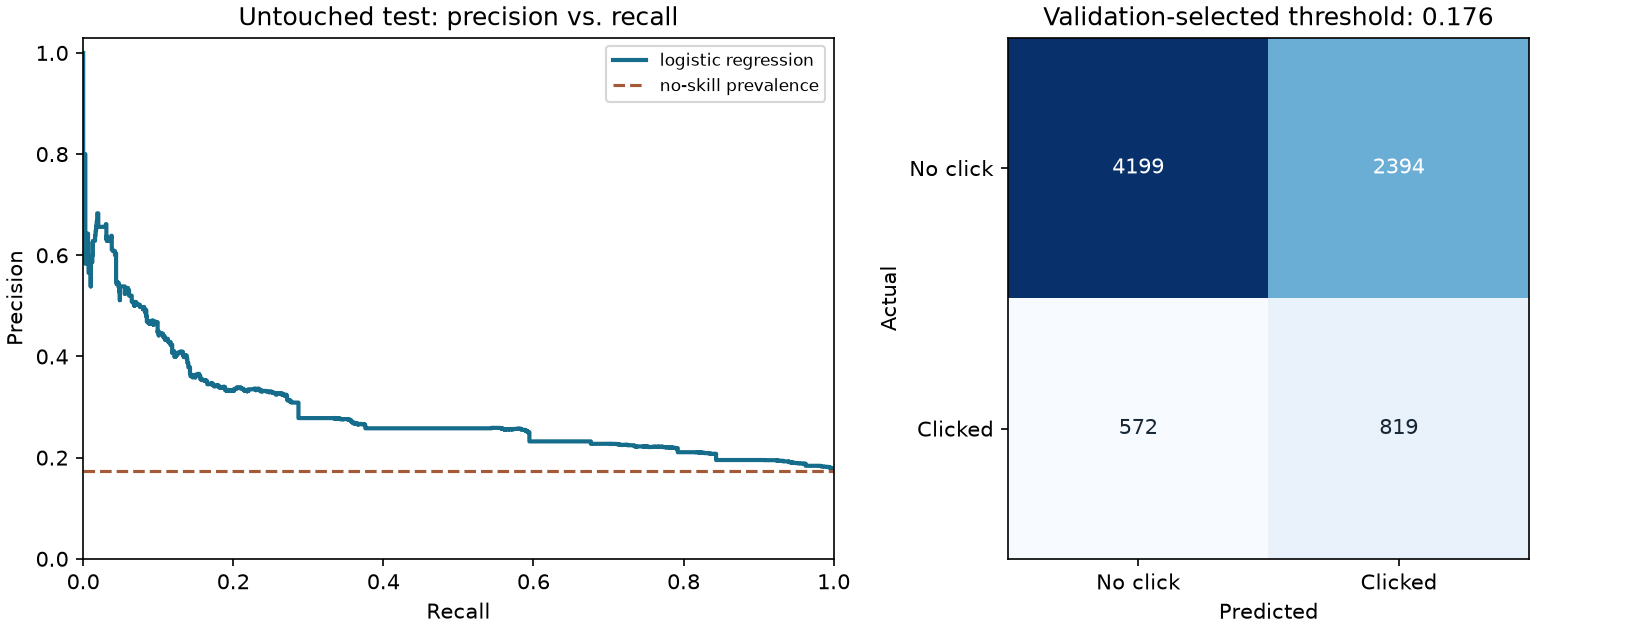

# Click Through Rate / Click Propensity — reproducible results

Predict whether an ad was clicked using Tencent/KDD Cup 2012 data distributed as OpenML dataset 1220. The supplied 39,948-row subset is explicitly downsampled by its publisher. Use depth, position, and categorical ad/query attributes available when selecting an ad; exclude post-event view counts, click timestamps, and aggregate impression counts. Known users are kept in one partition, and identical anonymous contexts are grouped together.

## Evaluation design

Seed 42. Training, validation, and test row counts: 23,957,
7,985, 7,984.
Preprocessing is fitted inside the training pipeline. Model selection uses validation
log_loss; the decision threshold maximizes validation F1.
The selected model is **logistic_regression**. No tuning uses the test labels.

## Untouched test results

| Measure | Selected model | Constant-prevalence baseline |
|---|---:|---:|
| Average precision | 0.2890 | 0.1742 |
| ROC AUC | 0.6475 | 0.5000 |
| Log loss (lower is better) | 0.4397 | 0.4626 |
| Brier score (lower is better) | 0.1370 | 0.1439 |
| Precision | 0.2549 | 0.0000 |
| Recall | 0.5888 | 0.0000 |
| F1 | 0.3558 | 0.0000 |
| Accuracy | 0.6285 | 0.8258 |

At threshold **0.1756**, the model produces **3,213** positive flags:
**819** true positives and **2,394** false positives.
It misses **572** positives; **4,199** negatives are correctly rejected.
Test positive prevalence is **17.42%**, across 7,984 rows.

![Precision–recall curve and confusion matrix](evaluation.png)

## Interpretation and limits

Model selection minimizes validation log loss because the task needs useful click-propensity scores, rather than recall obtained by flagging almost every impression. The F1-selected threshold is a demonstration decision rule, not an ad-serving policy. `ranking_lift.csv` shows the observed clicks captured within fixed ranking budgets on the untouched test set. Upstream negative downsampling changes prevalence: predicted scores and observed rates describe this benchmark, not a campaign's actual CTR. No timestamp is supplied, so temporal drift remains untested. The original receipt-ad MySQL data is unavailable; this benchmark is a replacement and does not reproduce the historical notebook's 93% recall claim. Production CTR requires representative impression logs, calibration on natural prevalence, and a time-based holdout.

See [all candidate metrics](metrics.csv), [auditable test predictions](predictions.csv),
[split assignments](splits.csv), and [run metadata, input hash, and package versions](metrics.json).
Numbers here are generated by the script, not copied from the historical notebook.


In [4]:
display(Image(filename=str(ROOT / 'results/evaluation.png')))
display(Markdown((ROOT / 'results/REPORT.md').read_text()))

## Auditable outputs

The scores below are held-out predictions, not training predictions.

In [5]:
display(pd.read_csv(ROOT / 'results/predictions.csv').head(10))

,row_id,actual,baseline_score,logistic_regression_score,predicted,random_forest_score
0,5,1,0.168886,0.189796,1,0.179315
1,6,0,0.168886,0.110812,0,0.150503
2,8,0,0.168886,0.179244,1,0.137042
3,15,0,0.168886,0.165279,0,0.175924
4,16,0,0.168886,0.114462,0,0.151281
5,29,0,0.168886,0.148144,0,0.162390
6,31,0,0.168886,0.176576,1,0.177442
7,35,0,0.168886,0.216714,1,0.168569
8,44,1,0.168886,0.199366,1,0.179657
9,58,0,0.168886,0.165515,0,0.172391


## Inference on new rows

Use the saved preprocessing pipeline and the validation-selected threshold. These three example rows come from the public input; they illustrate the interface and do not provide a new performance estimate.

In [6]:
from predict import predict
display(predict(ROOT / 'examples/new_rows.csv', ROOT / 'results/model.joblib', ROOT / 'results/new_predictions.csv'))

,row_id,positive_score,predicted
0,0,0.072615,0
1,1,0.181010,1
2,2,0.165515,0


## Task-specific checks

These outputs expose model errors, interpretation, or ranking performance instead of relying on a single headline score.

In [7]:
print('ranking_lift.csv')
display(pd.read_csv(ROOT / 'results/ranking_lift.csv').head(10))

ranking_lift.csv


,review_fraction,rows,observed_click_rate,lift_vs_test_prevalence,clicks_captured
0,0.05,400,0.412500,2.367649,165
1,0.10,799,0.332916,1.910857,266
2,0.20,1597,0.283657,1.628121,453
3,0.50,3992,0.233216,1.338605,931
4,1.00,7984,0.174223,1.000000,1391


## What these results establish

Negative downsampling changes prevalence, so these scores and rates cannot be reported as population or campaign CTR. Without timestamps, temporal drift remains untested. Ranking lift is measured only on this downsampled benchmark; absolute click probability needs calibration on natural-prevalence logs.

See `data/provenance.json` and `results/metrics.json` for provenance and run settings. The numbers shown here come from this execution.